In [1]:


import os
os.chdir(os.pardir)

from src.utils import AIDatasetLoader, filter_by_app_and_model, DecisionTreeInterpreter, LogisticRegressionInterpreter  
from src.memory import Chunk, DeclarativeMemory

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load datasets

In [2]:
current_dir = os.getcwd()
data_dir = os.path.join(current_dir, 'datasets')

file_values = os.path.join(data_dir, 'values.csv')
file_metadata = os.path.join(data_dir, 'metadata.csv')
file_prediction = os.path.join(data_dir, 'none.csv')

values_df = pd.read_csv(file_values)
metadata_df = pd.read_csv(file_metadata)
prediction_df = pd.read_csv(file_prediction)

# ✅ Which model to use per dataset
dataset_model_map = {
    "mushrooms": "mlp",
    "wine_quality": "mlp",
    "forest_cover": "xgboost",
    "adult": "xgboost",
}

# # 🔧 Choose dataset here:
# app_id = "wine_quality"  # 🔄 Change this line to switch datasets

# # 🧠 Auto-configured values:
# model_name = dataset_model_map[app_id]

# load ai loader
ai_dataset_loader = AIDatasetLoader(
    feature_values_df=values_df,
    metadata_df=metadata_df,
    AI_predictions_df=prediction_df
)

# Load decision tree
dt_df = pd.read_csv(os.path.join(data_dir, 'decision_tree.csv'))
# dt_exp = DecisionTreeInterpreter(dt_df, metadata_df, app_id, model_name, depth=2)
# dt_exp.print_tree(as_name=True)


# Load linear model
lr_df = pd.read_csv(os.path.join(data_dir, 'logistic_regression.csv'))
# lr_exp = LogisticRegressionInterpreter(lr_df, metadata_df, app_id, model_name, variant="sparse")

In [3]:
# ✅ Which model to use per dataset
dataset_model_map = {
    "mushrooms": "mlp",
    "wine_quality": "mlp",
    "forest_cover": "mlp",
    "adult": "mlp",
}

# 🔧 Choose dataset here:
# 📋 Dataset mapping dictionary
dataset_mapping = {
    1: "wine_quality",
    2: "mushrooms", 
    3: "forest_cover",
    4: "adult"
}

app_id1 = dataset_mapping[1]  # wine_quality
app_id2 = dataset_mapping[2]  # mushrooms
app_id3 = dataset_mapping[3]  # forest_cover
app_id4 = dataset_mapping[4]  # adult

# 🧠 Auto-configured values:
model_name1 = dataset_model_map[app_id1]
model_name2 = dataset_model_map[app_id2]
model_name3 = dataset_model_map[app_id3]
model_name4 = dataset_model_map[app_id4]

# load ai loader
ai_dataset_loader = AIDatasetLoader(
    feature_values_df=values_df,
    metadata_df=metadata_df,
    AI_predictions_df=prediction_df
)

ai_data_loader1 = filter_by_app_and_model(ai_dataset_loader, app_id1, model_name1)
ai_data_loader2 = filter_by_app_and_model(ai_dataset_loader, app_id2, model_name2)
ai_data_loader3 = filter_by_app_and_model(ai_dataset_loader, app_id3, model_name3)
ai_data_loader4 = filter_by_app_and_model(ai_dataset_loader, app_id4, model_name4)

# instances, preds = ai_dataset_loader.load_instances(list(range(20)), normalize=False)  # Load instances

# Load decision tree
dt_df = pd.read_csv(os.path.join(data_dir, 'decision_tree.csv'))
dt_exp1 = DecisionTreeInterpreter(dt_df, metadata_df, app_id1, model_name1)
dt_exp1.print_tree(as_name=True)
dt_exp2 = DecisionTreeInterpreter(dt_df, metadata_df, app_id2, model_name2)
dt_exp2.print_tree(as_name=True)
dt_exp3 = DecisionTreeInterpreter(dt_df, metadata_df, app_id3, model_name3)
dt_exp3.print_tree(as_name=True)
dt_exp4 = DecisionTreeInterpreter(dt_df, metadata_df, app_id4, model_name4)
dt_exp4.print_tree(as_name=True)


# Load linear model
lr_df = pd.read_csv(os.path.join(data_dir, 'logistic_regression.csv'))
lr_exp1 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id1, model_name1)
lr_exp2 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id2, model_name2)
lr_exp3 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id3, model_name3)
lr_exp4 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id4, model_name4)
lr_exp5 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id1, model_name1, variant="sparse")
lr_exp6 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id2, model_name2, variant="sparse")
lr_exp7 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id3, model_name3, variant="sparse")
lr_exp8 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id4, model_name4, variant="sparse")

ai_dataset_loaders = {
    1: ai_data_loader1,
    2: ai_data_loader2,
    3: ai_data_loader3,
    4: ai_data_loader4,
    5: ai_data_loader1,
    6: ai_data_loader2,
    7: ai_data_loader3,
    8: ai_data_loader4
}

lr_exps = {
    1: lr_exp1,     
    2: lr_exp2,
    3: lr_exp3,
    4: lr_exp4,
    5: lr_exp5,     
    6: lr_exp6,
    7: lr_exp7,
    8: lr_exp8
}


Decision Tree (appId=wine_quality, model=mlp)
Fidelity: 0.9550
if Alcohol <= 10.849999904632568:
  if Vinegar Taint <= 0.375:
    if Sulphates <= 0.6049999892711639:
      → Predict 0 (probs: [0.8 0.2])
    else:
      → Predict 1 (probs: [0. 1.])
  else:
    if Sulphates <= 1.64000004529953:
      → Predict 0 (probs: [0.9818 0.0182])
    else:
      → Predict 1 (probs: [0. 1.])
else:
  if Vinegar Taint <= 0.5649999976158142:
    if Sulphates <= 0.5049999952316284:
      → Predict 0 (probs: [0.5 0.5])
    else:
      → Predict 1 (probs: [0. 1.])
  else:
    if Alcohol <= 12.400000095367432:
      → Predict 0 (probs: [0.8889 0.1111])
    else:
      → Predict 1 (probs: [0. 1.])
Decision Tree (appId=mushrooms, model=mlp)
Fidelity: 0.8000
if Height <= 3.4250000715255737:
  if Cap Diameter <= 3.284999966621399:
    if Shape = flat <= 0.5:
      → Predict 0 (probs: [1. 0.])
    else:
      → Predict 0 (probs: [0.6538 0.3462])
  else:
    if Width <= 3.944999933242798:
      → Predict 0 (pro

In [4]:

import importlib
import src.memory as memory
importlib.reload(memory)
import src.dt_memory as dt_memory
importlib.reload(dt_memory)
import src.heuristic_lr_model as heuristic_lr_model
importlib.reload(heuristic_lr_model)
import src.lr_memory as lr_memory
importlib.reload(lr_memory)

from src.memory import DeclarativeMemory, CombinedMemory
from src.dt_memory import (
    add_dt_to_memory, dt_traverse, refresh_dt_path_in_memory
)
from src.heuristic_lr_model import (
    add_lr_heuristic_to_memory, lr_heuristic, refresh_lr_heuristic_in_memory
)
from src.lr_memory import (
    add_lr_calculation_to_memory, lr_calculation, refresh_lr_calculation_in_memory
)

from typing import Optional
import random
from dataclasses import replace

In [5]:
# ---------------- Memory builder ----------------
def _make_memory(retrieval_threshold, latency_factor):
    dm = DeclarativeMemory(
        retrieval_threshold=retrieval_threshold,
        latency_factor=latency_factor,
        latency_exponent=0.5,
        max_assoc_strength=2.0,
        mismatch_penalty=-2.0,
        activation_noise=0.3,
        decay=0.5,
    )
    return CombinedMemory(dm, wm_capacity=7)

# def _select_prob(probs, y):
#     if hasattr(probs, "__len__") and len(probs) == 2:
#         return float(probs[1]) if float(y) > 0 else float(probs[0])
#     raise ValueError(f"Unexpected probs format: {probs}")


# ---------------- Strategy adapters ----------------
# def _seed_memory_for_strategy(strategy, memory, explainer, compute_sf):
#     """
#     Initializes memory for the chosen strategy.
#     """
#     if strategy == "lr_calc":
#         # preload LR coefficients for calculation path
#         add_lr_calculation_to_memory(explainer, memory)
#     elif strategy == "lr_heur":
#         # preload LR heuristic state (use your preferred init var)
#         add_lr_heuristic_to_memory(explainer, memory, initial_var=1.0)
#     elif strategy == "dt":
#         # preload DT structure (threshold sig figs follow compute_sf)
#         add_dt_to_memory(memory, explainer, thresh_sf=int(compute_sf))
#     else:
#         raise ValueError(f"Unknown strategy: {strategy!r}")


def _predict_once(strategy, instance, norm_instance, memory, explainer, *, with_xai,
                  T_enc, T_op, ddm_a, ddm_s, compute_sf):
    """
    Runs ONE trial under the chosen strategy and returns:
      probs, pred_time, aux_info
    """
    if strategy == "lr_calc":
        # lr_calculation in 'read' or 'retrieve'
        probs, pred_time, aux = lr_calculation(
            instance, memory, lr_exp=explainer,
            T_enc=T_enc, T_op=T_op, ddm_a=ddm_a, ddm_s=ddm_s,
            compute_sf=compute_sf,
            mode=("read" if with_xai else "retrieve"),
        )
        return probs, pred_time, aux

    elif strategy == "lr_heur":
        # heuristic maps T_enc->T_READ_NUM, T_op->T_INTUITIVE_OP
        probs, pred_time, info = lr_heuristic(
            norm_instance, memory, explainer,
            num_samples=64, K_top=3,
            T_READ_NUM=T_enc,
            ddm_a=ddm_a, ddm_s=ddm_s, ddm_Tnd=0.30, ddm_norm="l2",
            active_indices=None, verbose=False
        )
        return probs, pred_time, info

    elif strategy == "dt":
        # dt_traverse in 'read' or 'retrieve'
        probs, pred_time, aux = dt_traverse(
            instance, memory, explainer,
            mode=("read" if with_xai else "retrieve"),
            compute_sf=int(compute_sf),
            T_enc=T_enc, ddm_a=ddm_a, ddm_s=ddm_s, ddm_Tnd=0.30, ddm_norm="l2",
            n_mc=64, topk_k=3, refresh_prob_cap=1.0, verbose=False
        )
        return probs, pred_time, aux

    else:
        raise ValueError(f"Unknown strategy: {strategy!r}")


def _post_read_refresh(strategy, memory, explainer, *, compute_sf, info_or_aux, instance, with_xai, actual_label, active_indices=None):
    """
    Applies post-read/online refresh depending on strategy.
    - For lr_calc: refresh only when with_xai=True (as before).
    - For lr_heur: refresh on BOTH. If with_xai=False, use model’s own pred as 'actual'.
    - For dt:      after read, refresh the path; retrieve-mode may use refresh_prob_cap internally.
    """
    if strategy == "lr_calc":
        if with_xai:
            refresh_lr_calculation_in_memory(
                memory, explainer,
                intercept_display_sf=int(compute_sf),
                factor_display_sf=int(compute_sf),
                #active_indices=active_indices
            )

    elif strategy == "lr_heur":
        # 'info_or_aux' is the 'info' dict returned by lr_heuristic
        info = info_or_aux
        # actual_label already set by caller to either human response (with XAI) or model pred (w/o XAI)
        refresh_lr_heuristic_in_memory(
            memory, explainer, info, actual=int(actual_label),
            active_indices=active_indices, w_min=1e-4, verbose=False
        )

    elif strategy == "dt":
        if with_xai:
            # refresh the path after reading explanations
            # (thresh_sf ties to compute_sf for consistency)
            refresh_dt_path_in_memory(memory, explainer, instance, thresh_sf=int(compute_sf))

In [6]:
# import numpy as np
# import gymnasium as gym
# from gymnasium import spaces

# # ===================== Action → Mode mapping (outside the class) =====================
# # 1: "with XAI"  -> lr_calculation(..., mode="read")
# # 2: "without XAI" -> lr_calculation(..., mode="retrieve")
# LR_ACTIONS = {
#     1: "read",
#     2: "retrieve",
# }


# class LRForward(gym.Env):
#     """
#     Logistic-heuristic environment with a binary feature-mask action.

#     Actions (MultiDiscrete of length max_features):
#       • action[i] ∈ {0,1}: whether feature i (in the *shuffled* index space) is active.

#     Trial schedule:
#       • Each episode samples a boolean schedule of "with-XAI" trials according to xai_trial_ratio.
#       • The "with-XAI" flag affects post-read refresh/learning behavior, not the action space.

#     Observation (float32 Box normalized to [0,1]):
#       [
#         chi_norm,                      # χ scaled to [0,1] by (chi_low, chi_high)
#         trial_idx_norm,                # step_idx / instances_per_episode
#         with_xai_flag,                 # {0,1}
#         mu_norm[0:max_features],       # per-feature coefficient means (μ), normalized
#         var_norm[0:max_features],      # per-feature coefficient variances, normalized
#         (optional) varied cognitive params if cog_params provides ranges
#       ]

#     Reward:
#       reward = prob_correct - chi * pred_time
#       where prob_correct is the model's predicted probability for the true label (with optional lapse),
#       and pred_time is the predicted decision time for the trial.

#     Notes:
#       • Features are permuted per episode. Actions index into the *shuffled* space;
#         the env maps to original feature indices for the model call.
#       • μ/var are read deterministically from memory chunk slots (no retrieval noise).
#     """


#     metadata = {"render_modes": ["human"]}

#     def __init__(
#         self,
#         *,
#         instances_per_episode: int = 40,
#         max_features: int = 6,
#         chi_low: float = 0.0,
#         chi_high: float = 0.03,
#         xai_trial_ratio: float = 0.5,         # fraction of trials that are with-XAI
#         ai_dataset_loaders=None,              # dict[key] -> loader
#         lr_exps=None,                         # dict[key] -> LR explainer
#         training: bool = True,
#         cog_params: dict = None,              # dict of defaults or ranges (lo,hi)
#         complexity: str = "low",              # kept for compatibility
#     ):
#         super().__init__()

#         self.shuffle_features = True
#         self.perm = None
#         self.inv_perm = None


#         self.instances_per_episode = int(instances_per_episode)
#         self.max_features = int(max_features)
#         self.chi_low = float(chi_low)
#         self.chi_high = float(chi_high)
#         self.xai_trial_ratio = float(xai_trial_ratio)

#         self.ai_dataset_loaders = ai_dataset_loaders or {}
#         self.lr_exps = lr_exps or {}

#         # Action = strategy id (1..2) + feature mask (binary per feature)
#         self.action_space = spaces.MultiDiscrete([2] * self.max_features) 

#         # Cognitive params (episode-varying)
#         self.cog_params = cog_params or {}
#         self.num_varied_cogparam = 0
#         self.varied_cogparams_low = []
#         self.varied_cogparams_high = []
#         for k, v in self.cog_params.items():
#             if isinstance(v, (list, tuple)) and len(v) == 2:
#                 self.num_varied_cogparam += 1
#                 self.varied_cogparams_low.append(float(v[0]))
#                 self.varied_cogparams_high.append(float(v[1]))

#         # -------- Observation space --------
#         low_vec = [0.0, 0.0, 0.0]                        # chi_norm, trial_norm, with_xai_flag
#         high_vec = [1.0, 1.0, 1.0]

#         # low_vec += [0.0] * 2                             # strategy_counts (lo)
#         # high_vec += [float(self.instances_per_episode)] * 2

#         # low_vec += [0.0] * 2                             # strategy_success rates (lo)
#         # high_vec += [1.0] * 2

#         low_vec += [0.0] * self.max_features             # per-feature std distribution (lo)
#         high_vec += [1.0] * self.max_features            # per-feature std distribution (hi)

#         low_vec += [0.0] * self.max_features             # per-feature mean distribution (lo)
#         high_vec += [1.0] * self.max_features            # per-feature mean distribution (hi)

#         if self.num_varied_cogparam > 0:
#             low_vec += self.varied_cogparams_low
#             high_vec += self.varied_cogparams_high

#         self.observation_space = spaces.Box(
#             low=np.array(low_vec, dtype=np.float32),
#             high=np.array(high_vec, dtype=np.float32),
#             dtype=np.float32,
#         )

#         # Episode state
#         self.step_idx = 0
#         self.curr_chi = 0.0
#         self.training = bool(training)
#         self.complexity = complexity

#         self.memory = None
#         self.lr_exp = None
#         self.ai_dataset_loader = None

#         self.strategy_counts = np.zeros(2, dtype=np.int32)   # [count_read, count_retrieve]
#         self.strategy_success = np.zeros(2, dtype=np.float32)

#         self.contributions = {i: [] for i in range(self.max_features)}
#         self.current_cog_params = {}
#         self.with_xai_schedule = None

#     # ---------------------- internal helpers ----------------------

#     def _initialize_memory(self):
#         """
#         Build memory using _make_memory with only retrieval_threshold and latency_factor
#         possibly varying episode-by-episode.
#         """
#         rt = float(self.current_cog_params.get("retrieval_threshold", 0.5))
#         lf = float(self.current_cog_params.get("latency_factor", 3.0))
#         self.memory = _make_memory(rt, lf)

#         # Seed LR calculation knowledge in memory
#         if self.lr_exp is not None:
#             add_lr_heuristic_to_memory(self.lr_exp, self.memory, initial_var=1.0)

#         # Warm-up time
#         self.memory.tick(90)

#     def _get_strategy_params(self):
#         """
#         Collect lr_calculation knobs (timing/diffusion/precision), allowing
#         episode-varying overrides from self.current_cog_params.
#         """
#         params = dict(
#             T_enc=2.0,
#             T_op=0.2,
#             ddm_a=1.0,
#             ddm_s=1.0,
#             ddm_Tnd=0.30,
#             ddm_norm="l2",
#             compute_sf=2,
#             lapse=0.05,
#         )
#         for k, v in (self.current_cog_params or {}).items():
#             if k in params and isinstance(v, (int, float)):
#                 params[k] = float(v)
#         return params

#     def _build_with_xai_schedule(self, n, ratio, rng):
#         """
#         Return np.array of length n with booleans for with-XAI trials.
#         """
#         n_xai = int(round(n * ratio))
#         flags = np.array([1] * n_xai + [0] * (n - n_xai), dtype=np.int32)
#         rng.shuffle(flags)
#         return flags.astype(bool)

#     def _build_obs(self):
#         # If episode ended, return a valid zero-like observation
#         if self.step_idx >= self.instances_per_episode:
#             return np.zeros(self.observation_space.shape, dtype=np.float32)

#         with_xai_flag = float(self.with_xai_schedule[self.step_idx])

#         self.mus = []
#         self.vars = []

#         for key, coef in self.lr_exp.coefficients.items():
#             cname = f"LR_coef_prob_{key.replace('=', '_')}"
#             chunk = self.memory.get_chunk(cname)
#             mu = chunk.slots.get("mu", 0.0)
#             var = chunk.slots.get("var", 0.0)
#             self.mus.append(mu)
#             self.vars.append(var)
        
#         mu_array = np.array(self.mus, dtype=np.float32)
#         var_array = np.array(self.vars, dtype=np.float32)
#         if abs(mu_array).sum() > 0:
#             mu_norm = (abs(mu_array) / (abs(mu_array).sum() + 1e-9)).astype(np.float32)
#         else:
#             mu_norm = mu_array
#         if var_array.sum() > 0:
#             var_norm = (var_array / (var_array).sum()).astype(np.float32)
#         else:
#             var_norm = var_array

#         # # Feature contribution tracking
#         # x_raw = self.X_raw[self.step_idx]
#         # for feat in range(min(self.max_features, x_raw.shape[-1])):
#         #     if self.lr_exp is not None and hasattr(self.lr_exp, "coefficients"):
#         #         factor_value = self.lr_exp.coefficients.get(f"a{feat}", 0.0)
#         #     else:
#         #         factor_value = 0.0
#         #     self.contributions[feat].append(float(x_raw[feat]) * float(factor_value))

#         # # per-feature std distribution
#         # feature_stds = np.array([
#         #     np.std(self.contributions[i]) if len(self.contributions[i]) > 1 else 0.0
#         #     for i in range(self.max_features)
#         # ], dtype=np.float32)
#         # if feature_stds.sum() > 0:
#         #     partial_sums_std = (feature_stds / feature_stds.sum()).astype(np.float32)
#         # else:
#         #     partial_sums_std = feature_stds

#         # # per-feature mean distribution (normalized)
#         # feature_means = np.array([
#         #     np.mean(self.contributions[i]) if len(self.contributions[i]) > 0 else 0.0
#         #     for i in range(self.max_features)
#         # ], dtype=np.float32)
#         # if abs(feature_means).sum() != 0:
#         #     partial_sums_mean = (abs(feature_means) / (abs(feature_means).sum() + 1e-9)).astype(np.float32)
#         # else:
#         #     partial_sums_mean = feature_means

#         # Get LR factor values and stds from internal model
        


#         if self.perm is not None:
#             # partial_sums_std = partial_sums_std[self.perm]
#             # partial_sums_mean = partial_sums_mean[self.perm]
#             var_norm = var_norm[self.perm]
#             mu_norm = mu_norm[self.perm]

#         base = [
#             float(self.curr_chi / max(self.chi_high, 1e-9)),
#             float(self.step_idx / max(self.instances_per_episode, 1)),
#             with_xai_flag,
#             # *self.strategy_counts.tolist(),
#             # *self.strategy_success.tolist(),
#             # *partial_sums_std.tolist(),
#             # *partial_sums_mean.tolist(),  # Added mean distribution
#             *var_norm.tolist(),
#             *mu_norm.tolist(),
#         ]

#         if self.num_varied_cogparam > 0:
#             cog_obs = [
#                 float(self.current_cog_params.get(k, 0.0))
#                 for k, v in self.cog_params.items()
#                 if isinstance(v, (list, tuple)) and len(v) == 2
#             ]
#             base += cog_obs

#         return np.asarray(base, dtype=np.float32)

#     # --------------------------- Gym API ---------------------------

#     def reset(self, seed=None, options=None):
#         super().reset(seed=seed)
#         rng = np.random.default_rng(seed)

#         # Per-episode feature permutation
#         if self.shuffle_features:
#             self.perm = rng.permutation(self.max_features).astype(np.int64)           # shuf_pos -> orig_idx (if index 1 in the shuffled list, then self.perm[1] gives the original index)
#             inv = np.empty_like(self.perm)
#             inv[self.perm] = np.arange(self.max_features, dtype=np.int64)
#             self.inv_perm = inv
#         else:
#             self.perm = np.arange(self.max_features, dtype=np.int64)
#             self.inv_perm = np.arange(self.max_features, dtype=np.int64)

#         # Randomly select dataset key and bind loader/exp
#         if not self.ai_dataset_loaders:
#             raise RuntimeError("ai_dataset_loaders is empty.")
#         dataset_key = rng.choice(list(self.ai_dataset_loaders.keys()))
#         self.ai_dataset_loader = self.ai_dataset_loaders[dataset_key]
#         self.lr_exp = (self.lr_exps or {}).get(dataset_key, None)

#         # Episode-varying cognitive params
#         self.current_cog_params = {}
#         for k, v in (self.cog_params or {}).items():
#             if isinstance(v, (list, tuple)) and len(v) == 2:
#                 self.current_cog_params[k] = float(rng.uniform(v[0], v[1]))
#             elif isinstance(v, (int, float)):
#                 self.current_cog_params[k] = float(v)

#         # Build memory via _make_memory
#         self._initialize_memory()

#         # With-XAI schedule for the whole episode
#         self.with_xai_schedule = self._build_with_xai_schedule(
#             self.instances_per_episode, self.xai_trial_ratio, rng
#         )

#         self.step_idx = 0
#         self.curr_chi = float(rng.uniform(self.chi_low, self.chi_high))

#         # Reset trackers
#         self.strategy_counts[:] = 0
#         self.strategy_success[:] = 0.0
#         # self.contributions = {i: [] for i in range(self.max_features)}

#         # Sample instances for the episode (adapt to your dataset size)
#         all_idx = list(range(1, 400))
#         idx = rng.choice(all_idx, size=self.instances_per_episode, replace=False).tolist()
#         inst_raw, labels = self.ai_dataset_loader.load_instances(idx, normalize=False)
#         inst_norm, _ = self.ai_dataset_loader.load_instances(idx, normalize=True)
#         self.X_raw = np.asarray(inst_raw, dtype=np.float32)
#         self.X_norm = np.asarray(inst_norm, dtype=np.float32)
#         self.y = np.asarray(labels, dtype=np.int64)



#         return self._build_obs(), {}

#     def step(self, action):
#         action = np.asarray(action, dtype=np.int64)
#         # action_id = int(action[0])
#         mask_bits = action[:].tolist()
#         active_shuf = [i for i, b in enumerate(mask_bits[:self.max_features]) if b == 1]

#         active_indices = [int(self.perm[i]) for i in active_shuf]  # map to original indices

#         # active_indices = [0]
#         # active_indices = [0, 1, 3, 4,]

#         # Invalid action id (0 or >2) → penalty
#         # if action_id not in LR_ACTIONS:
#         #     self.step_idx += 1
#         #     truncated = self.step_idx >= self.instances_per_episode
#         #     info = {"error": f"Invalid action id {action_id}", "chi": self.curr_chi}
#         #     return self._build_obs(), -5.0, False, truncated, info



#         # Trial mode constraints
#         with_xai_trial = bool(self.with_xai_schedule[self.step_idx])
#         # chosen_mode = LR_ACTIONS[action_id]  # "read" or "retrieve"

#         # If the trial is without-XAI, only "retrieve" is allowed
#         # if (not with_xai_trial) and (chosen_mode == "read"):
#         #     self.step_idx += 1
#         #     truncated = self.step_idx >= self.instances_per_episode
#         #     info = {
#         #         "invalid_on_no_xai_trial": True,
#         #         "chosen_mode": chosen_mode,
#         #         "with_xai_trial": with_xai_trial,
#         #     }
#         #     return self._build_obs(), -3.0, False, truncated, info


#         # Fetch current instance
#         x_raw = self.X_raw[self.step_idx]
#         x_norm = self.X_norm[self.step_idx]
#         y_true = int(self.y[self.step_idx])

#         # Params for lr_calculation
#         SP = self._get_strategy_params()

#         # Run lr_calculation in the chosen mode
#         probs, pred_time, info = lr_heuristic(
#             x_norm, self.memory, self.lr_exp,
#             num_samples=64, K_top=3,
#             T_enc=SP["T_enc"],
#             ddm_a=SP["ddm_a"], ddm_s=SP["ddm_s"], ddm_Tnd=0.30, ddm_norm="l2",
#             active_indices=active_indices, verbose=False
#         )

#         # Post-read refresh
#         _post_read_refresh(
#             "lr_heur", self.memory, self.lr_exp,
#             compute_sf=SP["compute_sf"],
#             info_or_aux=info,
#             instance=x_raw,
#             with_xai=with_xai_trial,
#             actual_label=y_true,
#             active_indices=active_indices
#         )

#         # if chosen_mode=="read":
#         #     # Post-read refresh
#         #     _post_read_refresh(
#         #         "lr_calc", self.memory, self.lr_exp,
#         #         compute_sf=SP["compute_sf"],
#         #         info_or_aux=None,
#         #         instance=x_raw,
#         #         with_xai=with_xai_trial,
#         #         actual_label=None,
#         #         #active_indices=active_indices
#         #     )

#         # Reward
#         prob_correct = float(probs[y_true])
#         if SP["lapse"] > 0.0:
#             prob_correct = (1.0 - SP["lapse"]) * prob_correct + 0.5 * SP["lapse"]
#         reward = prob_correct - float(self.curr_chi) * float(pred_time)

#         # Update per-strategy stats (index 0: read, 1: retrieve)
#         # idx = 0 if (chosen_mode == "read") else 1
#         # self.strategy_counts[idx] += 1
#         # n = self.strategy_counts[idx]
#         # old_mean = self.strategy_success[idx]
#         # self.strategy_success[idx] = (old_mean * (n - 1) + (1.0 if prob_correct > 0.5 else 0.0)) / max(n, 1)

#         # Advance
#         self.step_idx += 1
#         truncated = self.step_idx >= self.instances_per_episode
            
#         obs = self._build_obs()
#         info = {
#             "action_id": None,
#             "chosen_mode": None,
#             "with_xai_trial": with_xai_trial,
#             "prob_correct": prob_correct,
#             "pred_time": float(pred_time),
#             "chi": self.curr_chi,
#             "cog_params": dict(self.current_cog_params),
#         }
#         return obs, float(reward), False, truncated, info


In [7]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces

class LRForward(gym.Env):
    """
    LR-heuristic environment with:
      • Action = [ddm_a_bin, feature-mask...]
      • Observation = SAME as your heuristic version:
          [chi_norm, trial_idx_norm, with_xai_flag,
           var_norm[0:F], mu_norm[0:F], (optional ranged cog-params...)]

    Reward: prob_correct - chi * pred_time
    """

    metadata = {"render_modes": ["human"]}

    def __init__(
        self,
        *,
        instances_per_episode: int = 40,
        max_features: int = 6,
        xai_trial_ratio: float = 0.5,
        ai_dataset_loaders=None,          # dict[key] -> loader
        lr_exps=None,                     # dict[key] -> LR explainer
        training: bool = True,
        cog_params: dict = None,          # may include {"chi":(lo,hi), "ddm_a":(lo,hi)} and other (lo,hi)
        complexity: str = "low",
        ddm_a_bins: int = 3               # number of discrete bins for ddm_a choice
    ):
        super().__init__()

        self.shuffle_features = True
        self.perm = None
        self.inv_perm = None

        self.instances_per_episode = int(instances_per_episode)
        self.max_features = int(max_features)
        self.xai_trial_ratio = float(xai_trial_ratio)

        self.ai_dataset_loaders = ai_dataset_loaders or {}
        self.lr_exps = lr_exps or {}

        # --- ddm_a range (defaults to fixed 1.0 if not provided as a range) ---
        self.ddm_a_min, self.ddm_a_max = 1.0, 1.0
        if cog_params and isinstance(cog_params.get("ddm_a", None), (list, tuple)) and len(cog_params["ddm_a"]) == 2:
            self.ddm_a_min = float(cog_params["ddm_a"][0])
            self.ddm_a_max = float(cog_params["ddm_a"][1])

        self.ddm_a_bins = int(ddm_a_bins)
        assert self.ddm_a_bins >= 2, "Use at least 2 bins for ddm_a."

        # --- chi range (used per-episode & normalized in obs) ---
        chi_low, chi_high = 0.0, 0.03
        if cog_params and isinstance(cog_params.get("chi", None), (list, tuple)) and len(cog_params["chi"]) == 2:
            chi_low, chi_high = float(cog_params["chi"][0]), float(cog_params["chi"][1])
        self.chi_low = chi_low
        self.chi_high = chi_high

        # --- Action space: [ddm_a_bin, mask_0..mask_{F-1}] ---
        self.action_space = spaces.MultiDiscrete([self.ddm_a_bins] + [2] * self.max_features)

        # --- Cognitive params (episode-varying) ---
        self.cog_params = cog_params or {}
        self.num_varied_cogparam = 0
        self.varied_cogparams_low = []
        self.varied_cogparams_high = []
        for k, v in self.cog_params.items():
            # we will treat any (lo,hi) param as "varied" *except* ddm_a and chi which are handled above
            if k in ["chi", "ddm_a"]:
                continue
            if isinstance(v, (list, tuple)) and len(v) == 2:
                self.num_varied_cogparam += 1
                self.varied_cogparams_low.append(float(v[0]))
                self.varied_cogparams_high.append(float(v[1]))

        # --- Observation space (IDENTICAL layout to your heuristic env) ---
        # [chi_norm, trial_norm, with_xai_flag,
        #  var_norm[0:F], mu_norm[0:F], (optional ranged cog-params...)]
        low_vec  = [0.0, 0.0, 0.0]
        high_vec = [1.0, 1.0, 1.0]
        low_vec  += [0.0] * self.max_features  # var_norm
        high_vec += [1.0] * self.max_features
        low_vec  += [0.0] * self.max_features  # mu_norm
        high_vec += [1.0] * self.max_features
        if self.num_varied_cogparam > 0:
            low_vec  += self.varied_cogparams_low
            high_vec += self.varied_cogparams_high

        self.observation_space = spaces.Box(
            low=np.array(low_vec, dtype=np.float32),
            high=np.array(high_vec, dtype=np.float32),
            dtype=np.float32,
        )

        # Episode state
        self.step_idx = 0
        self.curr_chi = 0.0
        self.training = bool(training)
        self.complexity = complexity

        self.memory = None
        self.lr_exp = None
        self.ai_dataset_loader = None

        self.current_cog_params = {}
        self.with_xai_schedule = None

        # scratch for obs building
        self._mus_cache = None
        self._vars_cache = None

    # ---------------------- helpers ----------------------

    def _ddm_a_from_bin(self, bin_idx: int) -> float:
        """Map ddm_a bin → scalar in [ddm_a_min, ddm_a_max] using bin midpoints."""
        b = int(np.clip(bin_idx, 0, self.ddm_a_bins - 1))
        if self.ddm_a_bins == 1 or self.ddm_a_min == self.ddm_a_max:
            return float(self.ddm_a_min)
        frac = (b + 0.5) / self.ddm_a_bins
        return float(self.ddm_a_min + frac * (self.ddm_a_max - self.ddm_a_min))

    def _initialize_memory(self):
        rt = float(self.current_cog_params.get("retrieval_threshold", 0.5))
        lf = float(self.current_cog_params.get("latency_factor", 3.0))
        self.memory = _make_memory(rt, lf)

        # Seed heuristic “knowledge”
        if self.lr_exp is not None:
            # you already have this util in your codebase:
            add_lr_heuristic_to_memory(self.lr_exp, self.memory, initial_var=0.1)

        self.memory.tick(90)

    def _get_strategy_params(self):
        # Same knobs as your heuristic env (ddm_a will be set from the action)
        params = dict(
            T_enc=2.0,
            T_op=0.2,
            ddm_a=1.0,
            ddm_s=1.0,
            ddm_Tnd=0.30,
            ddm_norm="l2",
            compute_sf=2,
            lapse=0.05,
        )
        for k, v in (self.current_cog_params or {}).items():
            if k in params and isinstance(v, (int, float)) and k != "ddm_a":
                params[k] = float(v)
        return params

    def _build_with_xai_schedule(self, n, ratio, rng):
        n_xai = int(round(n * ratio))
        flags = np.array([1] * n_xai + [0] * (n - n_xai), dtype=np.int32)
        rng.shuffle(flags)
        return flags.astype(bool)

    def _read_mu_var_from_memory(self):
        """Deterministically read μ/var for each feature from memory chunks, then normalize."""
        mus, vars_ = [], []
        # expects lr_exp.coefficients like {"a0": w0, "a1": w1, ...}
        for key in range(self.max_features):
            cname = f"LR_coef_prob_a{key}"
            ch = self.memory.get_chunk(cname)
            mu = ch.slots.get("mu", 0.0) if ch is not None else 0.0
            var = ch.slots.get("var", 0.0) if ch is not None else 0.0
            mus.append(mu)
            vars_.append(var)

        mu_arr = np.array(mus, dtype=np.float32)
        var_arr = np.array(vars_, dtype=np.float32)

        if var_arr.sum() > 0:
            var_norm = (var_arr / var_arr.sum()).astype(np.float32)
        else:
            var_norm = var_arr

        if np.abs(mu_arr).sum() > 0:
            mu_norm = (np.abs(mu_arr) / (np.abs(mu_arr).sum() + 1e-9)).astype(np.float32)
        else:
            mu_norm = mu_arr

        return mu_norm, var_norm

    def _build_obs(self):
        if self.step_idx >= self.instances_per_episode:
            return np.zeros(self.observation_space.shape, dtype=np.float32)

        with_xai_flag = float(self.with_xai_schedule[self.step_idx])

        mu_norm, var_norm = self._read_mu_var_from_memory()
        
        # apply episode permutation
        if self.perm is not None:
            mu_norm = mu_norm[self.perm]
            var_norm = var_norm[self.perm]

        base = [
            float(self.curr_chi / max(self.chi_high, 1e-9)),
            float(self.step_idx / max(self.instances_per_episode, 1)),
            with_xai_flag,
            *var_norm.tolist(),
            *mu_norm.tolist(),
        ]
        if self.num_varied_cogparam > 0:
            base += [
                float(self.current_cog_params.get(k, 0.0))
                for k, v in self.cog_params.items()
                if isinstance(v, (list, tuple)) and len(v) == 2 and (k not in ["chi", "ddm_a"])
            ]
        return np.asarray(base, dtype=np.float32)

    # --------------------------- Gym API ---------------------------

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        rng = np.random.default_rng(seed)

        # Per-episode permutation over features
        if self.shuffle_features:
            self.perm = rng.permutation(self.max_features).astype(np.int64)
            inv = np.empty_like(self.perm)
            inv[self.perm] = np.arange(self.max_features, dtype=np.int64)
            self.inv_perm = inv
        else:
            self.perm = np.arange(self.max_features, dtype=np.int64)
            self.inv_perm = np.arange(self.max_features, dtype=np.int64)

        # Choose dataset/explainer
        if not self.ai_dataset_loaders:
            raise RuntimeError("ai_dataset_loaders is empty.")
        dataset_key = rng.choice(list(self.ai_dataset_loaders.keys()))
        self.ai_dataset_loader = self.ai_dataset_loaders[dataset_key]
        self.lr_exp = (self.lr_exps or {}).get(dataset_key, None)

        # Episode-varying cognitive params (except chi & ddm_a which are handled separately)
        self.current_cog_params = {}
        for k, v in (self.cog_params or {}).items():
            if isinstance(v, (list, tuple)) and len(v) == 2:
                self.current_cog_params[k] = float(rng.uniform(v[0], v[1]))
            elif isinstance(v, (int, float)):
                self.current_cog_params[k] = float(v)

        self._initialize_memory()

        # With-XAI schedule
        self.with_xai_schedule = self._build_with_xai_schedule(
            self.instances_per_episode, self.xai_trial_ratio, rng
        )

        self.step_idx = 0
        self.curr_chi = float(rng.uniform(self.chi_low, self.chi_high))

        # Sample instances
        all_idx = list(range(1, 400))
        idx = rng.choice(all_idx, size=self.instances_per_episode, replace=False).tolist()
        inst_raw, labels = self.ai_dataset_loader.load_instances(idx, normalize=False)
        inst_norm, _ = self.ai_dataset_loader.load_instances(idx, normalize=True)
        self.X_raw = np.asarray(inst_raw, dtype=np.float32)
        self.X_norm = np.asarray(inst_norm, dtype=np.float32)
        self.y = np.asarray(labels, dtype=np.int64)

        return self._build_obs(), {}

    def step(self, action):
        a = np.asarray(action, dtype=np.int64).reshape(-1)
        if a.shape[0] != (1 + self.max_features):
            return self._build_obs(), -5.0, False, False, {"error": "Bad action shape"}

        ddm_a_bin = int(a[0])
        mask_bits = a[1:1 + self.max_features].tolist()
        active_shuf = [i for i, b in enumerate(mask_bits) if b == 1]
        active_indices = [int(self.perm[i]) for i in active_shuf]

        # Trial metadata
        with_xai_trial = bool(self.with_xai_schedule[self.step_idx])

        # Fetch instance
        x_raw = self.X_raw[self.step_idx]
        x_norm = self.X_norm[self.step_idx]
        y_true = int(self.y[self.step_idx])

        # Params
        SP = self._get_strategy_params()
        SP["ddm_a"] = float(self._ddm_a_from_bin(ddm_a_bin))

        # Heuristic LR inference
        probs, pred_time, aux = lr_heuristic(
            x_norm, self.memory, self.lr_exp,
            num_samples=64, K_top=3,
            T_enc=SP["T_enc"],
            ddm_a=SP["ddm_a"], ddm_s=SP["ddm_s"], ddm_Tnd=0.30, ddm_norm="l2",
            active_indices=active_indices, verbose=False
        )

        # Post-read refresh/learning (with_xai flag influences update strength/paths in your util)
        _post_read_refresh(
            "lr_heur", self.memory, self.lr_exp,
            compute_sf=SP["compute_sf"],
            info_or_aux=aux,
            instance=x_raw,
            with_xai=with_xai_trial,
            actual_label=y_true,
            active_indices=active_indices
        )

        # Reward
        prob_correct = float(probs[y_true])
        if SP["lapse"] > 0.0:
            prob_correct = (1.0 - SP["lapse"]) * prob_correct + 0.5 * SP["lapse"]
        reward = prob_correct - float(self.curr_chi) * float(pred_time)

        # Advance
        self.step_idx += 1
        truncated = self.step_idx >= self.instances_per_episode

        obs = self._build_obs()
        info = {
            "with_xai_trial": with_xai_trial,
            "prob_correct": prob_correct,
            "pred_time": float(pred_time),
            "ddm_a": float(SP["ddm_a"]),
            "ddm_a_bin": int(ddm_a_bin),
            "active_indices_orig": active_indices,
            "active_indices_shuf": active_shuf,
            "chi": self.curr_chi,
            "cog_params": dict(self.current_cog_params),
        }
        return obs, float(reward), False, truncated, info


In [8]:
import os
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv
import torch.nn as nn
import time

In [9]:
lr_exp4.coefficients

OrderedDict([('a0', 5.380388718295755),
             ('a1', 0.03315775388255549),
             ('a2', 485.32405994167726),
             ('a3', 67.02968121782331),
             ('a4', 72.98385689164633),
             ('a5', 0.09585865105069157)])

## Run training loop

In [10]:
training_cog_params = {
    # Memory (used by _make_memory)
    "retrieval_threshold": [-2.0, 0.5],
    "latency_factor": [0.0, 0.5], #[1.0, 5.0],

    # lr_calculation parameters
    "T_enc": [0.5, 3.0], #[0.5, 3.0], #[1.0, 3.0],
    "T_op": [1.0, 3.0], #[0.05, 0.5],
    "ddm_a": [0.6, 1.7], #[0.8, 1.4],
    "ddm_s": [0.7, 1.1], #[0.8, 1.2], #[0.5, 1.2],
    "ddm_Tnd": 0.30,      # fixed is fine
    "ddm_norm": "l2",     # fixed is fine
    "compute_sf": 2.0, #[1.0, 3.0],
    "lapse": 0.05, #[0.01, 0.2],

    "chi": [0.0, 0.02], #[0.0, 0.03],
}

In [ ]:

# Make sure these are imported/defined somewhere:
# - LRForward (your new LR-only env)
# - ai_data_loader1, ai_data_loader2 (or however many you want)
# - lr_exp1, lr_exp2 (LR explainers)



def train_simple_chi_model(
    total_timesteps: int = 50_000,
    n_envs: int = 4,
    save_path: str = "./model_heuristic/simple_chi_model.zip",
    log_path: str = None,
    ppo_kwargs: dict = None,
) -> PPO:
    """
    Minimal PPO training loop for the LR-only LRForward environment.
    Extra PPO kwargs can be passed via `ppo_kwargs`.
    """
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # --------- vectorized env factory ---------
    def make_env(rank: int):
        def _init():
            # Example: two datasets; map small ints -> loaders/experts
            env = LRForward(
                instances_per_episode=40,
                max_features=6,
                xai_trial_ratio=0.5,    # fraction of with-XAI trials
                ai_dataset_loaders=ai_dataset_loaders,
                lr_exps=lr_exps,
                training=True,
                # Episode-varying cognitive parameters (ranges or fixed values)
                cog_params=training_cog_params,
                complexity="low",
            )
            return Monitor(env)
        return _init

    # --------- build vec envs (DummyVecEnv for simplicity) ---------
    # --------- build vec envs (SubprocVecEnv for parallel processing) ---------
    train_env = SubprocVecEnv([make_env(i) for i in range(n_envs)])
    eval_env = SubprocVecEnv([make_env(999)])
    
    # train_env = DummyVecEnv([make_env(i) for i in range(n_envs)])
    # eval_env = DummyVecEnv([make_env(999)])
    eval_env.training = False

    # --------- PPO defaults (override via ppo_kwargs) ---------
    default_kwargs = dict(
        policy="MlpPolicy",
        env=train_env,
        verbose=1,
        tensorboard_log=log_path,
        policy_kwargs=dict(
            net_arch=[dict(pi=[64, 64], vf=[64, 64])],
            activation_fn=nn.Tanh,
        ),
    )
    if ppo_kwargs:
        default_kwargs.update(ppo_kwargs)

    model = PPO(**default_kwargs)
    
    
    


    # --------- Eval callback ---------
    eval_freq = max(int(10000 / max(n_envs, 1)), 1)
    eval_callback = EvalCallback(
        eval_env,
        eval_freq=eval_freq,
        best_model_save_path=os.path.dirname(save_path),
    )


    print(f"🏃 Training for {int(total_timesteps):,} steps with {n_envs} env(s)...")
    print(f"📊 Expected rollout iterations: {total_timesteps // (2048 * n_envs)}")
    print(f"🔄 Evaluation frequency: every {eval_freq} timesteps")

    start_time = time.time()
    model.learn(total_timesteps=int(total_timesteps), callback=eval_callback, progress_bar=False)
    end_time = time.time()
    print(f"⏱️ Total training time: {(end_time - start_time):.2f} seconds")
    print(f"💾 Saving model to {save_path}")
    model.save(save_path)

    train_env.close()
    eval_env.close()
    return model


if __name__ == "__main__":
    # Example: run training with some PPO customizations
    model = train_simple_chi_model(
        total_timesteps=int(5e5),
        n_envs=8,
        ppo_kwargs=dict(
            learning_rate=3e-4,
            ent_coef=0.005,
            gamma=0.8,
            verbose=0,
            device="cpu",  # set to 'cuda' if you have a GPU
            n_steps=1024
        ),
    )


c:\Users\Louth\anaconda3\lib\site-packages\stable_baselines3\common\policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


🏃 Training for 500,000 steps with 8 env(s)...
📊 Expected rollout iterations: 30
🔄 Evaluation frequency: every 1250 timesteps
Eval num_timesteps=10000, episode_reward=20.37 +/- 0.83
Episode length: 40.00 +/- 0.00
New best mean reward!
Eval num_timesteps=20000, episode_reward=20.31 +/- 1.99
Episode length: 40.00 +/- 0.00
Eval num_timesteps=30000, episode_reward=20.93 +/- 1.87
Episode length: 40.00 +/- 0.00
New best mean reward!
Eval num_timesteps=40000, episode_reward=22.51 +/- 3.03
Episode length: 40.00 +/- 0.00
New best mean reward!
Eval num_timesteps=50000, episode_reward=20.77 +/- 0.75
Episode length: 40.00 +/- 0.00
Eval num_timesteps=60000, episode_reward=19.34 +/- 4.66
Episode length: 40.00 +/- 0.00
Eval num_timesteps=70000, episode_reward=18.57 +/- 7.02
Episode length: 40.00 +/- 0.00
Eval num_timesteps=80000, episode_reward=22.85 +/- 2.02
Episode length: 40.00 +/- 0.00
New best mean reward!
Eval num_timesteps=90000, episode_reward=20.07 +/- 4.73
Episode length: 40.00 +/- 0.00
Eval

# Evaluations and Plots

In [11]:
class LRForwardEval(LRForward):
    """
    Evaluation env that preserves the training observation space but allows fixing
    any subset of episode-varying cog params via eval_overrides.

    Args:
        training_cog_params: the SAME dict you used at training time (ranges & scalars).
        eval_overrides: dict of {param_name: fixed_value} to apply at eval.
        sample_remaining: if True, ranged params not in overrides are sampled per-episode;
                          if False (default), they use the midpoint of their training range.
    """
    def __init__(
        self,
        *,
        training_cog_params: dict,
        eval_overrides: dict = None,
        sample_remaining: bool = True,
        **base_kwargs,
    ):
        # Pass the training schema to preserve observation space
        super().__init__(cog_params=training_cog_params, training=False, **base_kwargs)
        self.eval_overrides = eval_overrides or {}
        self.sample_remaining = bool(sample_remaining)

    def _choose_value_from_range(self, lo: float, hi: float, rng):
        if self.sample_remaining:
            return float(rng.uniform(lo, hi))
        # deterministic midpoint (good for stable eval)
        return float(0.5 * (lo + hi))

    def reset(self, seed=None, options=None):
        # Same as parent but we replace how self.current_cog_params is built
        super().reset(seed=seed, options=options)  # this will set rng = np.random.default_rng(seed)
        # After parent reset we’ll overwrite current_cog_params deterministically/overrides.
        # Rebuild current_cog_params according to evaluation logic:
        rng = np.random.default_rng(seed)
        new_cog = {}

        for k, v in (self.cog_params or {}).items():
            # If user provided an override, use it (fixed)
            if k in self.eval_overrides:
                new_cog[k] = float(self.eval_overrides[k]) if isinstance(self.eval_overrides[k], (int, float)) else self.eval_overrides[k]
                continue

            # Keep scalars from training schema as-is (could be numeric or strings like "l2")
            if isinstance(v, (int, float, str)):
                new_cog[k] = v if isinstance(v, str) else float(v)
                continue

            # For ranges from training: use midpoint or sample, unless overridden
            if isinstance(v, (list, tuple)) and len(v) == 2:
                lo, hi = float(v[0]), float(v[1])
                new_cog[k] = self._choose_value_from_range(lo, hi, rng)
                continue

            # Fallback: copy through
            new_cog[k] = v

        self.current_cog_params = new_cog

        # Rebuild memory to reflect possibly changed memory-related params
        self._initialize_memory()

        # Return the observation the parent already produced (but after we set params/memory)
        return self._build_obs(), {}


In [12]:
training_cog_params

{'retrieval_threshold': [-2.0, 0.5],
 'latency_factor': [0.0, 0.5],
 'T_enc': [0.5, 3.0],
 'T_op': [1.0, 3.0],
 'ddm_a': [0.6, 1.7],
 'ddm_s': [0.7, 1.1],
 'ddm_Tnd': 0.3,
 'ddm_norm': 'l2',
 'compute_sf': 2.0,
 'lapse': 0.05,
 'chi': [0.0, 0.02]}

In [13]:
training_cog_params["ddm_s"] = [0.2, 1.1]

🔍 Evaluating model for 200 episodes...
📊 Completed 5/200 episodes
📊 Completed 10/200 episodes
📊 Completed 15/200 episodes
📊 Completed 20/200 episodes
📊 Completed 25/200 episodes
📊 Completed 30/200 episodes
📊 Completed 35/200 episodes
📊 Completed 40/200 episodes
📊 Completed 45/200 episodes
📊 Completed 50/200 episodes
📊 Completed 55/200 episodes
📊 Completed 60/200 episodes
📊 Completed 65/200 episodes
📊 Completed 70/200 episodes
📊 Completed 75/200 episodes
📊 Completed 80/200 episodes
📊 Completed 85/200 episodes
📊 Completed 90/200 episodes
📊 Completed 95/200 episodes
📊 Completed 100/200 episodes
📊 Completed 105/200 episodes
📊 Completed 110/200 episodes
📊 Completed 115/200 episodes
📊 Completed 120/200 episodes
📊 Completed 125/200 episodes
📊 Completed 130/200 episodes
📊 Completed 135/200 episodes
📊 Completed 140/200 episodes
📊 Completed 145/200 episodes
📊 Completed 150/200 episodes
📊 Completed 155/200 episodes
📊 Completed 160/200 episodes
📊 Completed 165/200 episodes
📊 Completed 170/200 epis

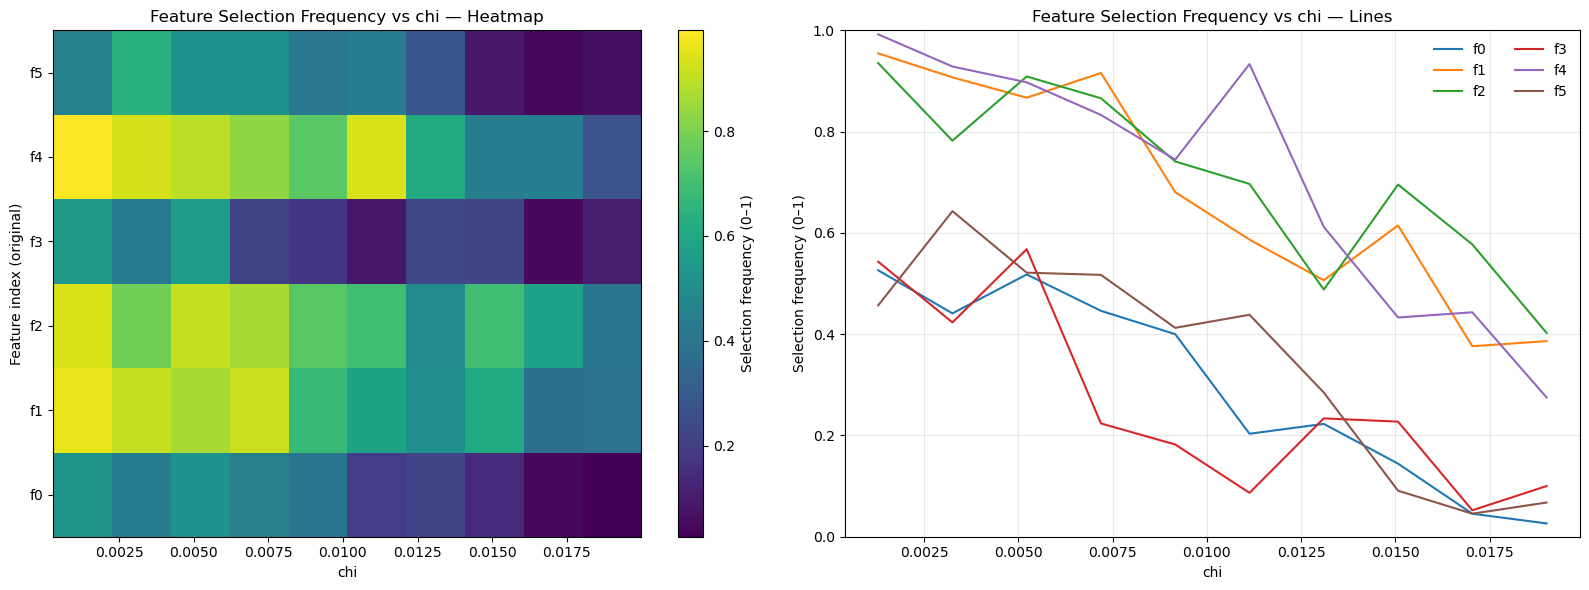

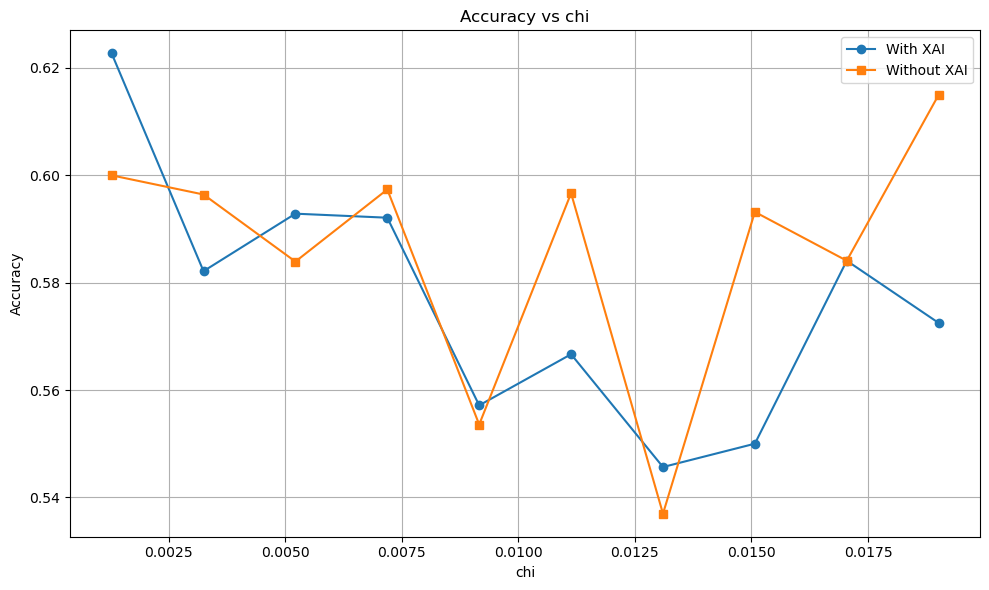

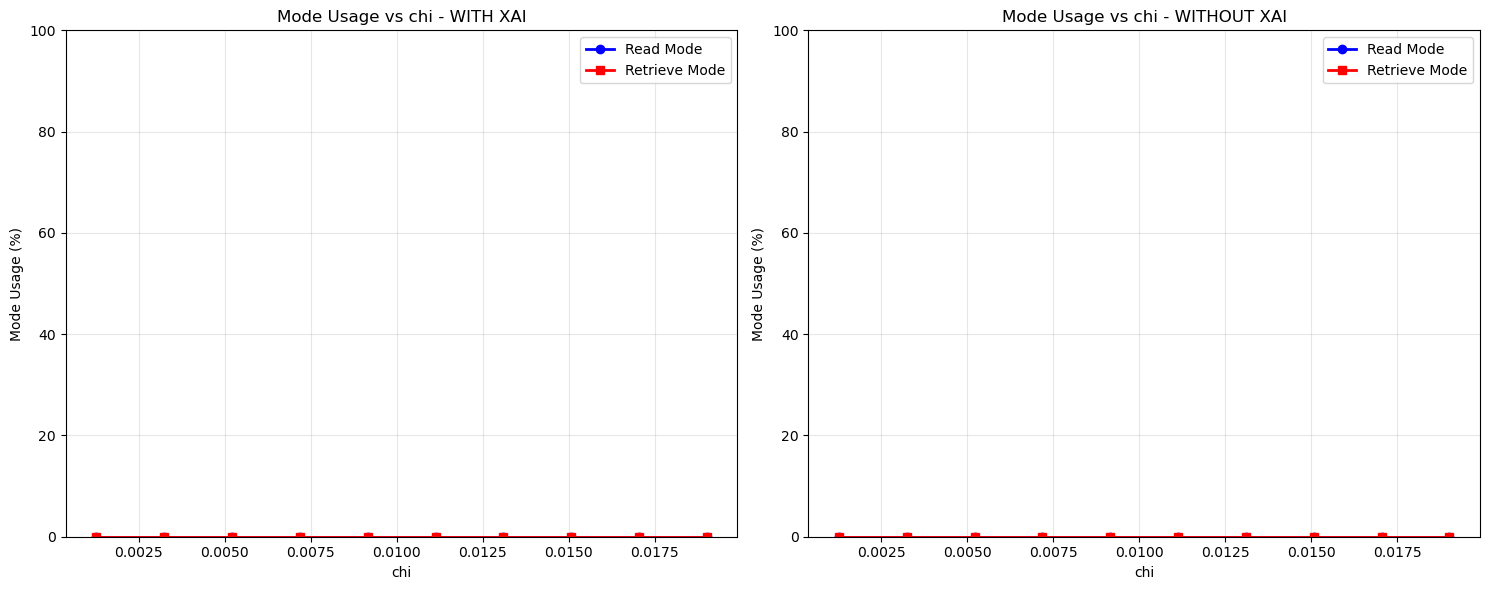


💾 Results saved to:
  - ./model_heuristic/evaluation_results.csv
  - ./model_heuristic/feature_selections.csv


In [17]:
def evaluate_trained_model(
    model_path: str = "./model_heuristic/simple_chi_model.zip",
    n_episodes: int = 40,
    render_results: bool = True
):
    model = PPO.load(model_path)

    # === What you want to lock/change at EVAL ===
    eval_overrides = {
        # Fix retrieval threshold & latency for evaluation:
        # "retrieval_threshold": -1.0,
        # "latency_factor": 0.0,

        # # Speed up encoding and set compute_sf deterministically:
        # "T_enc": 1.0,
        # "compute_sf": 2.0,

        # # Hold diffusion params constant for clean comparison:
        # "ddm_a": 1.0,
        # "ddm_s": 0.6,
        # "lapse": 0.05,
        # ddm_Tnd, ddm_norm were already fixed at training; no need to override
        # "ddm_s": 0.3,
    }



    def make_eval_env():
        env = LRForwardEval(
            instances_per_episode=40,
            max_features=6,
            # chi_low=0.0,
            # chi_high=0.01,          # match your earlier setup
            xai_trial_ratio=0.5,
            ai_dataset_loaders={6: ai_data_loader2},#{2: ai_data_loader2},#
            lr_exps={6: lr_exp6},#{2: lr_exp2},#
            complexity="low",
            training_cog_params=training_cog_params,  # preserves obs space
            eval_overrides=eval_overrides,            # fixes any subset you want
            sample_remaining=True,                   
        )
        return env

    eval_env = make_eval_env()

    # === your evaluation loop stays the same ===
    results = {
        "chi": [], "chosen_mode": [], "with_xai": [], "prob_correct": [], "pred_time": [],
        "reward": [], "feature_masks_shuf": [], "feature_masks_orig": [], "correct": []
    }

    varied_keys = [k for k, v in training_cog_params.items()
            if isinstance(v, (list, tuple)) and len(v) == 2]
    # Store per-step values of every varied cog param (and chi is already stored)
    for k in varied_keys:
        results[f"cog_{k}"] = []

    print(f"🔍 Evaluating model for {n_episodes} episodes...")

    for episode in range(n_episodes):
        obs, info = eval_env.reset()
        done = False
        while not done:
            action, _states = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = eval_env.step(action)
            done = terminated or truncated

            cog = info.get("cog_params", {})
            for k in varied_keys:
                # If a param was fixed by eval_overrides, it will still appear here (constant).
                val = cog.get(k, np.nan)
                results[f"cog_{k}"].append(val)

            # --- mask handling (unchanged) ---
            if len(action) >= eval_env.max_features + 1:
                feature_mask = action[1:eval_env.max_features + 1].astype(int)
            else:
                feature_mask = np.zeros(eval_env.max_features, dtype=int)
                feature_mask[:] = action[1:].astype(int)
            
            # print(action, feature_mask)

            # if len(feature_mask) != eval_env.max_features:
            #     temp_mask = np.zeros(eval_env.max_features, dtype=int)
            #     n = min(len(feature_mask), eval_env.max_features)
            #     temp_mask[:n] = feature_mask[:n]
            #     feature_mask = temp_mask

            perm = getattr(eval_env, "perm", None)
            if perm is None:
                perm = np.arange(eval_env.max_features, dtype=int)

            feature_mask_orig = np.zeros(eval_env.max_features, dtype=int)
            feature_mask_orig[perm] = feature_mask

            # --- log ---
            results["chi"].append(info.get("chi", 0.0))
            results["chosen_mode"].append(info.get("chosen_mode", "unknown"))
            results["with_xai"].append(info.get("with_xai_trial", False))
            results["prob_correct"].append(info.get("prob_correct", 0.0))
            results["pred_time"].append(info.get("pred_time", 0.0))
            results["reward"].append(reward)
            results["feature_masks_shuf"].append(feature_mask)
            results["feature_masks_orig"].append(feature_mask_orig)
            results["correct"].append(
                float(random.choices([0, 1], weights=[1 - info.get("prob_correct", 0.0),
                                                    info.get("prob_correct", 0.0)])[0])
            )

        if (episode + 1) % 5 == 0:
            print(f"📊 Completed {episode + 1}/{n_episodes} episodes")
            # print(f" Mus in last episode: {eval_env.mus}")
            # print(f" Vars in last episode: {eval_env.vars}")

    eval_env.close()

    # tidy up arrays …
    for key in list(results.keys()):
        if key not in ("feature_masks_shuf", "feature_masks_orig"):
            if isinstance(results[key], list):
                results[key] = np.asarray(results[key])
    results["feature_masks_shuf"] = np.stack(results["feature_masks_shuf"]).astype(int)
    results["feature_masks_orig"] = np.stack(results["feature_masks_orig"]).astype(int)


    # Print summary statistics
    print("\n" + "="*50)
    print("📈 EVALUATION SUMMARY")
    print("="*50)
    print(f"Mean Accuracy: {np.mean(results['correct']):.3f}")
    print(f"Mean Reward: {np.mean(results['reward']):.3f}")
    print(f"Mean Chi Value: {np.mean(results['chi']):.4f}")
    print(f"Mean Features Selected: {np.mean(np.sum(results['feature_masks_orig'], axis=1)):.1f}")
    
    # Mode usage
    mode_counts = pd.Series(results["chosen_mode"]).value_counts()
    for mode, count in mode_counts.items():
        pct = 100 * count / len(results["chosen_mode"])
        print(f"{mode.capitalize()} Mode Usage: {pct:.1f}%")
    print("="*50)
    
    if render_results:
        plot_feature_selection_heatmap(results, eval_env, which="orig", by="chi")
        plot_accuracy_vs(results, by="chi")
    

    return results, eval_env

def _values_and_bins(results, env, by="chi", n_bins=10):
    """
    Returns (xvals, bins) for binning.
    'by' can be 'chi' or any varied cog param name (e.g., 'ddm_a', 'T_enc', ...).
    """
    if by == "chi":
        xvals = results["chi"]
    else:
        key = f"cog_{by}"
        if key not in results:
            raise ValueError(f"'{by}' is not tracked. Available: 'chi' or "
                             f"{[k.removeprefix('cog_') for k in results.keys() if k.startswith('cog_')]}")
        xvals = results[key]

    # guard for degenerate single-value arrays
    xmin, xmax = float(np.nanmin(xvals)), float(np.nanmax(xvals))
    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmin == xmax:
        # make a tiny span to avoid zero-width bins
        xmin, xmax = xmin - 1e-6, xmax + 1e-6

    bins = np.linspace(xmin, xmax, n_bins + 1)
    return xvals, bins

def plot_accuracy_vs(results, by="chi", n_bins=10):
    """Plot accuracy vs any x-axis: 'chi' or a varied cog param (e.g., 'ddm_a')."""
    xvals, bins = _values_and_bins(results, env=None, by=by, n_bins=n_bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    correct = results["correct"]
    with_xai = results["with_xai"]

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    for flag_val, label, marker in [(True, "With XAI", "o"), (False, "Without XAI", "s")]:
        acc = []
        for i in range(n_bins):
            mask = (with_xai == flag_val) & (xvals >= bins[i]) & (xvals < bins[i+1])
            acc.append(np.nanmean(correct[mask]) if np.any(mask) else np.nan)
        ax.plot(bin_centers, acc, marker=marker, linestyle="-", label=label)

    ax.set_xlabel(by if by == "chi" else f"{by} (cog param)")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Accuracy vs {by}")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

def plot_feature_selection_heatmap(results, env, by="chi", n_bins=10, which="orig", show_legend=None):
    """
    Plots feature-selection frequency vs `by` as:
      • Left: heatmap (your original)
      • Right: line chart (one line per feature across bins)

    Args:
        results: evaluation dict
        env: the environment (for max_features)
        by: "chi" or a varied cog param name (e.g., "ddm_a")
        n_bins: number of bins for x-axis
        which: "orig" (recommended) or "shuf"
        show_legend: if None -> show legend only when max_features <= 10;
                     if True/False -> force legend on/off.
    """
    # --- binning & inputs ---
    xvals, bins = _values_and_bins(results, env, by, n_bins)
    if which == "orig":
        feature_masks = results["feature_masks_orig"]
        y_label = "Feature index (original)"
    elif which == "shuf":
        feature_masks = results["feature_masks_shuf"]
        y_label = "Feature index (shuffled)"
    else:
        raise ValueError("which must be 'orig' or 'shuf'")

    max_features = env.max_features
    bin_ids = np.digitize(xvals, bins) - 1
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # --- aggregate selection frequencies per bin ---
    avg_masks = np.zeros((n_bins, max_features), dtype=float)  # [bin, feat]
    counts = np.zeros(n_bins, dtype=float)

    for i, b in enumerate(bin_ids):
        if 0 <= b < n_bins:
            mask = feature_masks[i]
            if len(mask) != max_features:
                tmp = np.zeros(max_features, dtype=float)
                n = min(len(mask), max_features)
                tmp[:n] = mask[:n]
                mask = tmp
            mask = np.asarray(mask, dtype=float)
            avg_masks[b] += mask
            counts[b] += 1.0

    with np.errstate(invalid="ignore", divide="ignore"):
        avg_masks = np.divide(
            avg_masks, counts[:, None],
            out=np.zeros_like(avg_masks),
            where=counts[:, None] > 0
        )
    # avg_masks shape: (n_bins, max_features), values in [0, 1]

    # --- plotting: heatmap (left) + line chart (right) ---
    fig, (ax_hm, ax_ln) = plt.subplots(1, 2, figsize=(16, 6))

    # Heatmap
    im = ax_hm.imshow(
        avg_masks.T, aspect="auto", origin="lower",
        extent=[bins[0], bins[-1], 0, max_features],
        cmap="viridis"
    )
    cbar = plt.colorbar(im, ax=ax_hm, label="Selection frequency (0–1)")
    ax_hm.set_xlabel(by if by == "chi" else f"{by} (cog param)")
    ax_hm.set_ylabel(y_label)
    ax_hm.set_title(f"Feature Selection Frequency vs {by} — Heatmap")
    ax_hm.set_yticks(np.arange(max_features) + 0.5)
    ax_hm.set_yticklabels([f"f{i}" for i in range(max_features)])

    # Line chart: one line per feature across bins
    for feat in range(max_features):
        ax_ln.plot(
            bin_centers,
            avg_masks[:, feat],
            label=f"f{feat}",
        )
    ax_ln.set_xlabel(by if by == "chi" else f"{by} (cog param)")
    ax_ln.set_ylabel("Selection frequency (0–1)")
    ax_ln.set_title(f"Feature Selection Frequency vs {by} — Lines")
    ax_ln.set_ylim(0, 1)
    ax_ln.grid(True, alpha=0.3)

    # Legend policy (avoid clutter with many features)
    if show_legend is None:
        show_legend = (max_features <= 10)
    if show_legend:
        ax_ln.legend(ncol=2, frameon=False)

    plt.tight_layout()
    plt.show()

def plot_mode_usage_by_xai(results, env, by="chi", n_bins=10):
    """
    Plot mode usage (read vs retrieve) vs an x-axis ('chi' or any varied cog param),
    separated by with/without XAI trials.

    Args:
        results: dict from evaluation (must contain 'chosen_mode', 'with_xai',
                 'chi' or cog_<param> for non-chi plots)
        by: 'chi' or name of a varied cog param (e.g., 'ddm_a', 'T_enc', 'compute_sf')
        n_bins: number of bins on the x-axis
    """
    # Reuse generic binning (expects results["chi"] or results[f"cog_{by}"])
    xvals, bins = _values_and_bins(results, env=env, by=by, n_bins=n_bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    modes = np.asarray(results["chosen_mode"])
    with_xai = np.asarray(results["with_xai"], dtype=bool)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    colors  = {"read": "blue", "retrieve": "red"}
    markers = {"read": "o", "retrieve": "s"}
    panels = [
        (ax1, True,  "WITH XAI"),
        (ax2, False, "WITHOUT XAI"),
    ]

    # Helper to compute % usage per bin for a given mode and XAI flag
    def mode_pct_per_bin(target_mode, xai_flag):
        out = []
        for i in range(n_bins):
            # include right edge on last bin to capture max(xvals)
            in_bin = (xvals >= bins[i]) & ((xvals < bins[i+1]) if i < n_bins - 1 else (xvals <= bins[i+1]))
            mask = (with_xai == xai_flag) & in_bin
            if np.any(mask):
                bin_modes = modes[mask]
                out.append(100.0 * np.sum(bin_modes == target_mode) / len(bin_modes))
            else:
                out.append(np.nan)
        return out

    for ax, flag, title_suffix in panels:
        for mode_name in ["read", "retrieve"]:
            y = mode_pct_per_bin(mode_name, flag)
            ax.plot(
                bin_centers, y,
                marker=markers[mode_name], linestyle="-",
                color=colors[mode_name],
                label=f"{mode_name.capitalize()} Mode",
                linewidth=2, markersize=6,
            )
        x_label = by if by == "chi" else f"{by} (cog param)"
        ax.set_xlabel(x_label)
        ax.set_ylabel("Mode Usage (%)")
        ax.set_title(f"Mode Usage vs {by} - {title_suffix}")
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

# Run the evaluation
if __name__ == "__main__":
    results, eval_env = evaluate_trained_model(
        model_path="./model_heuristic/best_model.zip",
        n_episodes=200,
        render_results=True
    )
    
    # Additional plots
    # plot_mode_usage_vs_chi(results)
    plot_mode_usage_by_xai(results, env=eval_env, by="chi")
    # Save results
    results_df = pd.DataFrame({
        k: (v.tolist() if isinstance(v, np.ndarray) and v.ndim > 1 else v)
        for k, v in results.items()
        if k not in ("feature_masks_shuf", "feature_masks_orig")
    })

    
    # Save feature masks separately
    feature_df = pd.DataFrame(
        results["feature_masks_orig"], 
        columns=[f"feature_{i}" for i in range(results["feature_masks_orig"].shape[1])]
    )
    
    results_df.to_csv("./model_heuristic/evaluation_results.csv", index=False)
    feature_df.to_csv("./model_heuristic/feature_selections.csv", index=False)
    
    print("\n💾 Results saved to:")
    print("  - ./model_heuristic/evaluation_results.csv")
    print("  - ./model_heuristic/feature_selections.csv")

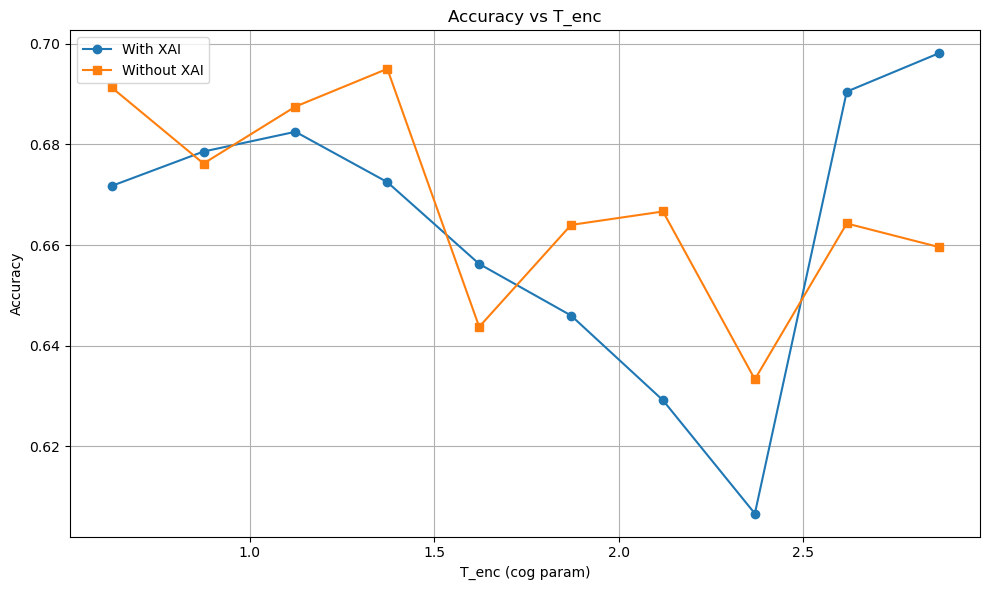

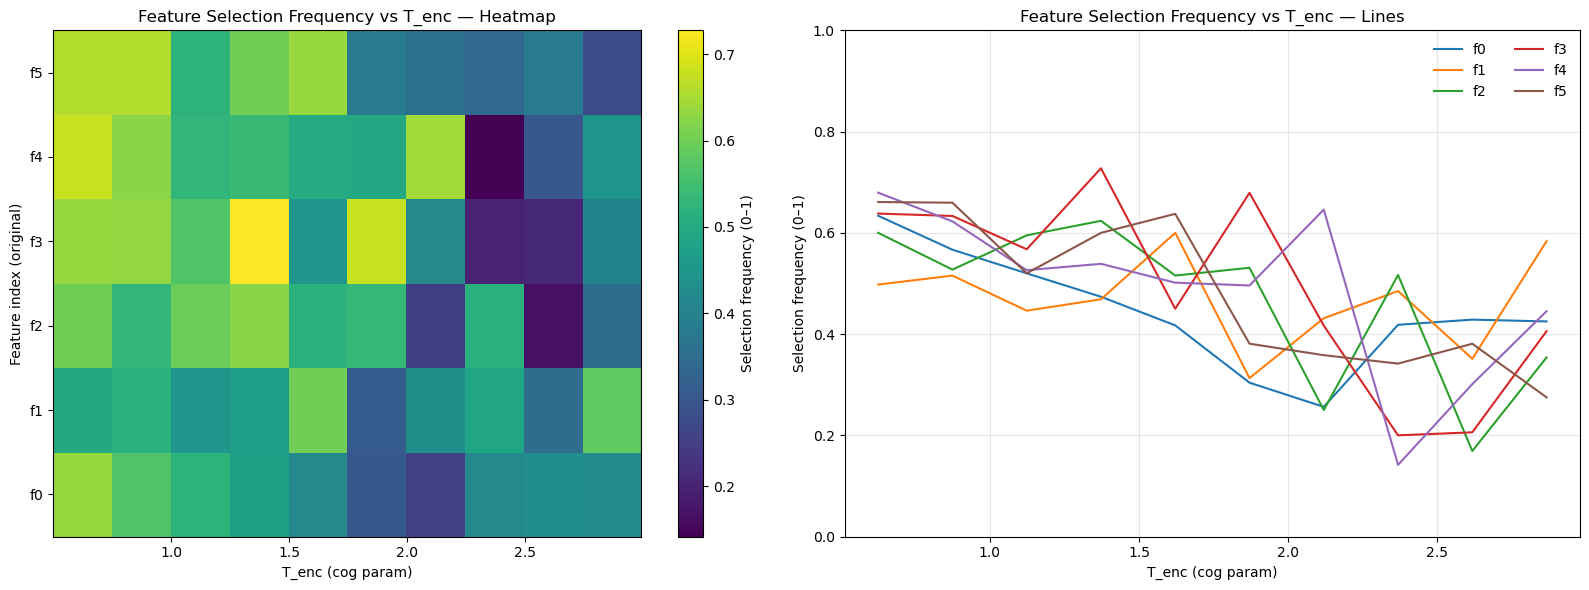

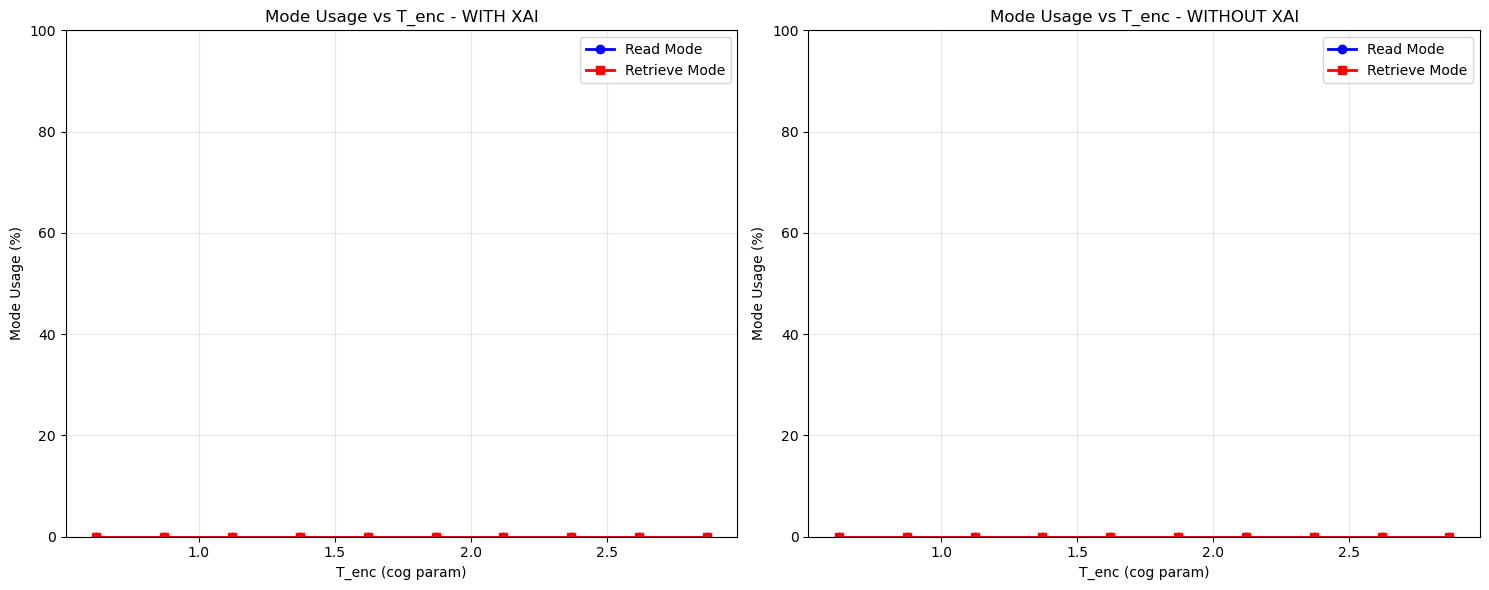

In [32]:
varied_param = "T_enc"  # example varied cog param
plot_accuracy_vs(results, by=varied_param, n_bins=10)
plot_feature_selection_heatmap(results, env=eval_env, by=varied_param, which="orig")
plot_mode_usage_by_xai(results, env=eval_env, by=varied_param)

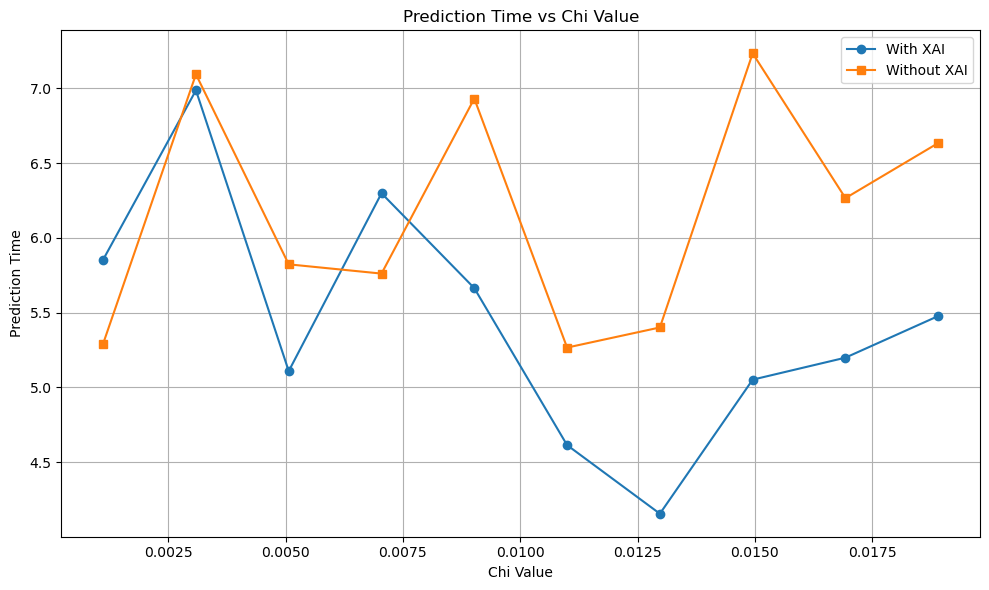

In [19]:
def plot_pred_time_vs_chi(results, n_bins=10):
    """
    Plot mean prediction time vs chi values, split by with/without XAI trials.
    """
    xvals = results["chi"]
    bins = np.linspace(xvals.min(), xvals.max(), n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    pred_time = results["pred_time"]
    with_xai = results["with_xai"]

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    # Plot by with_xai flag
    for flag_val, label, marker in [(True, "With XAI", "o"), (False, "Without XAI", "s")]:
        mean_times = []
        for i in range(n_bins):
            mask = (with_xai == flag_val) & (xvals >= bins[i]) & (xvals < bins[i + 1])
            mean_times.append(np.nanmean(pred_time[mask]) if np.any(mask) else np.nan)

        ax.plot(bin_centers, mean_times, marker=marker, linestyle="-", label=label)

    ax.set_xlabel("Chi Value")
    ax.set_ylabel("Prediction Time")
    ax.set_title("Prediction Time vs Chi Value")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

plot_pred_time_vs_chi(results)


In [16]:
# ...existing code...

def plot_feature_selection_by_xai_and_chi(results, n_bins=10):
    """
    Plot feature selection percentages vs chi values, separated by with/without XAI trials.
    Shows the percentage of times each feature (0-5) is selected across different chi values.
    """
    xvals = results["chi"]
    bins = np.linspace(xvals.min(), xvals.max(), n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    feature_masks = results["feature_masks"]
    with_xai = results["with_xai"]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Define colors for each feature
    colors = plt.cm.Set1(np.linspace(0, 1, feature_masks.shape[1]))
    markers = ['o', 's', '^', 'D', 'v', 'p']  # Different markers for each feature
    
    # Plot for WITH XAI trials
    for feature_idx in range(feature_masks.shape[1]):
        feature_pct = []
        for i in range(n_bins):
            # Filter for with_xai=True AND current chi bin
            mask = (with_xai == True) & (xvals >= bins[i]) & (xvals < bins[i + 1])
            if np.any(mask):
                bin_masks = feature_masks[mask]
                feature_count = np.sum(bin_masks[:, feature_idx])
                pct_val = 100 * feature_count / len(bin_masks)
                pct_val += np.random.uniform(-0.5, 0.5)   # small random jitter
                feature_pct.append(pct_val)
            else:
                feature_pct.append(np.nan)
        
        ax1.plot(bin_centers, feature_pct, 
                marker=markers[feature_idx % len(markers)], linestyle="-", 
                color=colors[feature_idx], label=f"Feature {feature_idx}",
                linewidth=2, markersize=6, alpha=0.8)
    
    ax1.set_xlabel("Chi Value")
    ax1.set_ylabel("Feature Selection (%)")
    ax1.set_title("Feature Selection vs Chi Value - WITH XAI Trials")
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-5, 105)
    
    # Plot for WITHOUT XAI trials
    for feature_idx in range(feature_masks.shape[1]):
        feature_pct = []
        for i in range(n_bins):
            # Filter for with_xai=False AND current chi bin
            mask = (with_xai == False) & (xvals >= bins[i]) & (xvals < bins[i + 1])
            if np.any(mask):
                bin_masks = feature_masks[mask]
                feature_count = np.sum(bin_masks[:, feature_idx])
                pct_val = 100 * feature_count / len(bin_masks)
                pct_val += np.random.uniform(-0.5, 0.5)   # small random jitter
                feature_pct.append(pct_val)
            else:
                feature_pct.append(np.nan)
        
        ax2.plot(bin_centers, feature_pct, 
                marker=markers[feature_idx % len(markers)], linestyle="-", 
                color=colors[feature_idx], label=f"Feature {feature_idx}",
                linewidth=2, markersize=6, alpha=0.8)
    
    ax2.set_xlabel("Chi Value")
    ax2.set_ylabel("Feature Selection (%)")
    ax2.set_title("Feature Selection vs Chi Value - WITHOUT XAI Trials")
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(-5, 105)
    
    plt.tight_layout()
    plt.show()

#
    # Additional plots

plot_feature_selection_by_xai_and_chi(results)  # Add this new plot
    
    # ...existing code...

KeyError: 'feature_masks'